## Profiling and optimizing netlists (Part 2)
Authored 10/11/2024

More experiments to determine how various simulation methods and whatnot affect simulation/training time. 
Distinct from the old notebook because the testing setup is a little different, and we want to test out transient simulations too, so the old data is not comparable.

In [56]:
%reload_ext autoreload
%autoreload 2

from helpers import *
from spice_net import *

import numpy as np
import networkx as nxs
import tqdm
import random
import json

import PySpice
PySpice.Spice.Simulation.CircuitSimulator.DEFAULT_SIMULATOR = "ngspice-shared" 
import PySpice.Spice.NgSpice.Server
PySpice.Spice.NgSpice.Server.SpiceServer.SPICE_COMMAND = 'ngspice'

In [60]:
import PySpice.Spice.NgSpice.Shared

instance = PySpice.Spice.NgSpice.Shared.NgSpiceShared.new_instance()

In [62]:
data = np.load("../data/xor_train_data_scale_1.0.npz")

In [63]:
def make_test_net(size, instance):
    seed = 0

    grid_size = size

    np.random.seed(seed)

    grid_graph = nx.grid_graph([grid_size, grid_size], periodic=True)
    # grid_graph.add_node((-1, -1))

    for e in grid_graph.edges:
        # grid_graph[e[0]][e[1]]['weight'] = 0.5                           # init to max value
        grid_graph[e[0]][e[1]]['weight'] = random.uniform(0.1, 0.9)       # random value

    node_cfg = (np.array([[5, 16], [7, 16], [13, 16], [15, 16]]), np.array([[10, 0]]))
    net: TransistorNetwork = TransistorNetwork("profiling", con_graph=grid_graph, node_cfg=node_cfg, solver='ngspice-shared', epsilon=1e-16)
    return net

def make_test_net_transient(size, instance):
    seed = 0

    grid_size = size

    np.random.seed(seed)

    grid_graph = nx.grid_graph([grid_size, grid_size], periodic=True)
    # grid_graph.add_node((-1, -1))

    for e in grid_graph.edges:
        # grid_graph[e[0]][e[1]]['weight'] = 0.5                           # init to max value
        grid_graph[e[0]][e[1]]['weight'] = random.uniform(0.1, 0.9)       # random value

    grid_graph = nx.convert_node_labels_to_integers(grid_graph, first_label=0, ordering='sorted')

    node_cfg = (np.array([[5, 16], [7, 16], [13, 16], [15, 16]]), np.array([[10, 0]]))
    twin_net = TwinNetwork('twin_net', grid_graph, node_cfg, 'ngspice-shared', t_h=u_us(100), period=u_us(200))
    return twin_net

## Experimental setup

In [64]:
# categorize relevant fields. We should still save all data just because
# the categories are super loose and we shouldn't read into them too much -
# it's just something I decided made sense to organize the data by.

netlist_fields = ["Subckt and Param expansion time", "Netlist parsing time"]
loading_fields = ["Netlist loading time", "Matrix load time", "Transient load time"]
matrix_fields = [
    "Matrix synchronize time",
    "Matrix reorder time",
    "Matrix factor time",
    "Matrix solve time",
]
misc_fields = [
    "Total analysis time (seconds)",
    "Total iterations",
    "Transient iterations",
    "Circuit Equations",
    "Circuit original non-zeroes",
    "Circuit fill-in non-zeroes",
    "Circuit total non-zeroes",
    "elapsed time since last call (seconds)",
]
tran_fields = [
    "Transient timepoints",
    "Accepted timepoints",
    "Rejected timepoints",
    "Transient analysis time",
    "Transient load time",
    "Transient sync time",
    "Transient factor time",
    "Transient solve time",
    "Transient trunc time",
    "Transient iterations for the last time point",
]
all_fields = netlist_fields + loading_fields + matrix_fields + misc_fields + tran_fields
all_fields = sorted(set(all_fields), key= lambda x: all_fields.index(x)) # remove duplicates

Methods to test in new benchmarks:
* DC "sweep" method (no caching) - this is our **new baseline**
* DC "sweep" method (with caching)
* Transient method
	* Set the simulation timestep small enough that SPICE simulates once per clock cycle "training step" - besides that, the automatic step size selection seems to choose timesteps that are plenty small (too small?)
	* Can possibly play around with the timescales of learning and whatnot
	
We should test all of these methods **with Sparse 1.3 and with KLU**
Should test all methods with **100 iterations** and **sum** all times.

In [65]:
# NET_SIZES = [4, 10, 20, 25, 50]
NET_SIZES = [4, 10, 20, 30, 40] # smaller networks for refinement study later on
N_ITERS = 100

In [66]:
net = make_test_net(4, instance)
net._prepare_simulation(data['inputs'])

In [67]:
print(str(net) + '.op\n')

.title profiling
.subckt transistor_edge t_D t_S vgs=0.5
V1 t_G t_S {vgs}
R1 t_D t_S 1e+16
M1 t_D t_G t_S t_S Ideal
.ends transistor_edge
B1 5 16 v={pwl(V(index), 1, 0.11, 2, 0.11, 3, 0.11, 4, 0.11)}
B2 7 16 v={pwl(V(index), 1, 0.33000000000000007, 2, 0.33000000000000007, 3, 0.33000000000000007, 4, 0.33000000000000007)}
B3 13 16 v={pwl(V(index), 1, 0.0, 2, 0.0, 3, 0.44999999999999996, 4, 0.44999999999999996)}
B4 15 16 v={pwl(V(index), 1, 0.0, 2, 0.44999999999999996, 3, 0.0, 4, 0.44999999999999996)}
Vindex index 0 1
X1 0 4 transistor_edge vgs=0.4803718741976386
X2 0 12 transistor_edge vgs=0.14019937222548082
X3 0 1 transistor_edge vgs=0.1226978558839611
X4 0 3 transistor_edge vgs=0.13349122503371078
X5 1 5 transistor_edge vgs=0.8950218497359841
X6 1 13 transistor_edge vgs=0.8236529593807588
X7 1 2 transistor_edge vgs=0.5274630735009984
X8 2 6 transistor_edge vgs=0.8746917475759606
X9 2 14 transistor_edge vgs=0.12900425905394047
X10 2 3 transistor_edge vgs=0.1795548350775067
X11 3 7 tran

In [54]:
instance.load_circuit(str(net) + '.op\n')

In [68]:
instance

In [71]:
res = net.cached_simulator.operating_point()

Using SPARSE 1.3 as Direct Linear Solver


In [72]:
res

In [80]:
print(instance.listing())

profiling
1 : profiling
2 : .global gnd
3 : .subckt transistor_edge t_d t_s params: vgs=0.5
5 : v1 t_g t_s {vgs}
6 : r1 t_d t_s 1e+16
7 : m1 t_d t_g t_s t_s ideal
8 : .ends transistor_edge
10 : b1 5 16 v= pwl ( v(index) ,   1.0000000000e+00 ,   1.1000000000e-01 ,   2.0000000000e+00 ,   1.1000000000e-01 ,   3.0000000000e+00 ,   1.1000000000e-01 ,   4.0000000000e+00 ,   1.1000000000e-01 )
12 : b2 7 16 v= pwl ( v(index) ,   1.0000000000e+00 ,   3.3000000000e-01 ,   2.0000000000e+00 ,   3.3000000000e-01 ,   3.0000000000e+00 ,   3.3000000000e-01 ,   4.0000000000e+00 ,   3.3000000000e-01 )
14 : b3 13 16 v= pwl ( v(index) ,   1.0000000000e+00 ,   0.0000000000e+00 ,   2.0000000000e+00 ,   0.0000000000e+00 ,   3.0000000000e+00 ,   4.5000000000e-01 ,   4.0000000000e+00 ,   4.5000000000e-01 )
16 : b4 15 16 v= pwl ( v(index) ,   1.0000000000e+00 ,   0.0000000000e+00 ,   2.0000000000e+00 ,   4.5000000000e-01 ,   3.0000000000e+00 ,   0.0000000000e+00 ,   4.0000000000e+00 ,   4.5000000000e-01 )
17 : 

In [131]:
net.subcircuit_names

odict_keys(['transistor_edge'])

In [146]:
instance.exec_command('print x1.vgs\n')

Warning from checkvalid: vector x1.vgs is not available or has zero length.


''

In [143]:
res.nodes

{'x32.t_g': WaveForm x32.t_g [0.30888187]@V,
 'x31.t_g': WaveForm x31.t_g [-0.00219988]@V,
 'x30.t_g': WaveForm x30.t_g [0.33803919]@V,
 'x29.t_g': WaveForm x29.t_g [0.69893611]@V,
 'x28.t_g': WaveForm x28.t_g [0.54164926]@V,
 'x27.t_g': WaveForm x27.t_g [0.38752963]@V,
 'x26.t_g': WaveForm x26.t_g [0.4708127]@V,
 'x25.t_g': WaveForm x25.t_g [0.82767469]@V,
 'x24.t_g': WaveForm x24.t_g [0.20760071]@V,
 'x23.t_g': WaveForm x23.t_g [0.80322129]@V,
 'x22.t_g': WaveForm x22.t_g [0.1607771]@V,
 'x21.t_g': WaveForm x21.t_g [0.1479685]@V,
 '11': WaveForm 11 [-0.00943418]@V,
 'x20.t_g': WaveForm x20.t_g [0.75231075]@V,
 'x19.t_g': WaveForm x19.t_g [0.40917625]@V,
 '10': WaveForm 10 [-0.05403299]@V,
 'x18.t_g': WaveForm x18.t_g [0.49474678]@V,
 'x17.t_g': WaveForm x17.t_g [0.6501628]@V,
 '9': WaveForm 9 [-0.06673014]@V,
 'x16.t_g': WaveForm x16.t_g [0.52703573]@V,
 'x15.t_g': WaveForm x15.t_g [0.82067928]@V,
 'x14.t_g': WaveForm x14.t_g [0.71166217]@V,
 '8': WaveForm 8 [-0.01657649]@V,
 'x13.t_

In [150]:
print(instance.listing())

profiling
1 : profiling
2 : .global gnd
3 : .subckt transistor_edge t_d t_s params: vgs=0.5
5 : v1 t_g t_s {vgs}
6 : r1 t_d t_s 1e+16
7 : m1 t_d t_g t_s t_s ideal
8 : .ends transistor_edge
10 : b1 5 16 v= pwl ( v(index) ,   1.0000000000e+00 ,   1.1000000000e-01 ,   2.0000000000e+00 ,   1.1000000000e-01 ,   3.0000000000e+00 ,   1.1000000000e-01 ,   4.0000000000e+00 ,   1.1000000000e-01 )
12 : b2 7 16 v= pwl ( v(index) ,   1.0000000000e+00 ,   3.3000000000e-01 ,   2.0000000000e+00 ,   3.3000000000e-01 ,   3.0000000000e+00 ,   3.3000000000e-01 ,   4.0000000000e+00 ,   3.3000000000e-01 )
14 : b3 13 16 v= pwl ( v(index) ,   1.0000000000e+00 ,   0.0000000000e+00 ,   2.0000000000e+00 ,   0.0000000000e+00 ,   3.0000000000e+00 ,   4.5000000000e-01 ,   4.0000000000e+00 ,   4.5000000000e-01 )
16 : b4 15 16 v= pwl ( v(index) ,   1.0000000000e+00 ,   0.0000000000e+00 ,   2.0000000000e+00 ,   4.5000000000e-01 ,   3.0000000000e+00 ,   0.0000000000e+00 ,   4.0000000000e+00 ,   4.5000000000e-01 )
17 : 

In [149]:
instance.exec_command('alter @X1.r1[r] = 1.0')

Error: no such device or model name x1.r1


NgSpiceCommandError: Command 'alter @X1.r1[r] = 1.0' failed

In [87]:
res

### DC simulation code:

In [36]:
# solver should either be 'Sparse' or 'KLU' for ngspice
SOLVER = 'KLU'
CACHE = True

out_string = "profiling_" + SOLVER.lower() + "_dc" + ("_cache" if CACHE else "") + "_reversed"
print(out_string)

profiling_klu_dc_cache_reversed


In [37]:
run_data = []

VOLTAGES_CACHE = [None] * 4

for size in tqdm.tqdm(NET_SIZES[::-1]):
    curr_run = dict(size=size, runs=[])
    for i in tqdm.tqdm(range(N_ITERS), leave=True):
        instance.remove_circuit()
        # net = make_test_net(size, None)
        net = make_test_net(size, instance)
        if SOLVER == 'Sparse':
            if "KLU" in net.cached_simulator._options:
                del net.cached_simulator._options["KLU"]
            net.cached_simulator.options("Sparse")
        elif SOLVER == 'KLU':
            if "Sparse" in net.cached_simulator._options:
                del net.cached_simulator._options["Sparse"]
            net.cached_simulator.options("KLU")
        else:
            raise ValueError("Invalid solver")

        if CACHE and (i > 4): 
            for j, v in enumerate(VOLTAGES_CACHE[i % 4]):
                if j == 0: continue
                net.cached_simulator.node_set(**{str(j): v[0]})
        res =  net.solve(data['inputs'][i % 4])
        curr_run["runs"].append(instance.ressource_usage())
        if CACHE:
            # update cache with most recent voltage values
            VOLTAGES_CACHE[i % 4] = res
    run_data.append(curr_run)

  0%|          | 0/5 [00:00<?, ?it/s]

Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as Direct Linear Solver
Using KLU as D

In [81]:
print(net.cached_simulator)

.title profiling
.subckt transistor_edge t_D t_S vgs=0.5
V1 t_G t_S {vgs}
R1 t_D t_S 1e+16
M1 t_D t_G t_S t_S Ideal
.ends transistor_edge
B1 5 16 v=0.11
B2 7 16 v=0.33000000000000007
B3 13 16 v=0.44999999999999996
B4 15 16 v=0.44999999999999996
Vindex index 0 1
X1 0 4 transistor_edge vgs=0.6317638509687491
X2 0 12 transistor_edge vgs=0.8666822128232509
X3 0 1 transistor_edge vgs=0.42738784724116774
X4 0 3 transistor_edge vgs=0.8316593146529557
X5 1 5 transistor_edge vgs=0.7086046397059748
X6 1 13 transistor_edge vgs=0.8412413291443711
X7 1 2 transistor_edge vgs=0.1897214931452373
X8 2 6 transistor_edge vgs=0.34329579708283975
X9 2 14 transistor_edge vgs=0.4758383962368459
X10 2 3 transistor_edge vgs=0.879140008389592
X11 3 7 transistor_edge vgs=0.5605258497038947
X12 3 15 transistor_edge vgs=0.12486801682287085
X13 4 8 transistor_edge vgs=0.8752915046426785
X14 4 5 transistor_edge vgs=0.3598174247716308
X15 4 7 transistor_edge vgs=0.5945990235948061
X16 5 9 transistor_edge vgs=0.355847

In [84]:
net.cached_simulator

In [99]:
instance.exec_command("version -f")

"******\n** ngspice-43 : Circuit level simulation program\n** Compiled with KLU Direct Linear Solver\n** The U. C. Berkeley CAD Group\n** Copyright 1985-1994, Regents of the University of California.\n** Copyright 2001-2024, The ngspice team.\n** Please get your ngspice manual from https://ngspice.sourceforge.io/docs.html\n** Please file your bug-reports at http://ngspice.sourceforge.net/bugrep.html\n**\n** CIDER 1.b1 (CODECS simulator) included\n** XSPICE extensions included\n** Relevant compilation options (refer to user's manual):\n** OpenMP multithreading for BSIM3, BSIM4 enabled\n** X11 interface not compiled into ngspice\n**\n** ngspice shared library.\n******"

In [85]:
instance.exec_command("rusage")

'Total analysis time (seconds) = 0.004\nTotal elapsed time (seconds) = 2178.207 \nTotal DRAM available = 16384.000 MB.\nDRAM currently available =  202.625 MB.\nMaximum ngspice program size = 0 bytes.\nCurrent ngspice program size =   98.281 MB.'

In [9]:
with open(f"{out_string}.json", "w") as f:
    json.dump(run_data, f, indent=4)

### Transient analysis code

In [20]:
NUDGE_FACTOR = 0.5

# solver should either be 'Sparse' or 'KLU' for ngspice
SOLVER = 'sparse'
# integration method should be either 'trap' or 'gear'
METHOD = 'trap'
trtol = 50

out_string = "profiling_" + SOLVER.lower() + "_" + METHOD.lower() + "_transient"
print(out_string)

profiling_sparse_trap_transient


In [21]:
run_data = []

for size in tqdm.tqdm(NET_SIZES):
    instance.remove_circuit()
    net = make_test_net_transient(size, instance)
    if SOLVER.lower() in ['klu', 'sparse']:
        net.cached_simulator._options.pop("klu", None)
        net.cached_simulator._options.pop("sparse", None)
        net.cached_simulator.options(SOLVER.lower())
    else:
        raise ValueError("Invalid solver")
    if METHOD.lower() in ['trap', 'gear']:
        net.cached_simulator._options.pop("trap", None)
        net.cached_simulator._options.pop("gear", None)
        net.cached_simulator.options(METHOD.lower())

    net.cached_simulator.options(trtol=trtol)
    net._prepare_simulation(data['inputs'], data['outputs'], nudge_factor=NUDGE_FACTOR)
    res = net.cached_simulator.transient(step_time=net.t_h, end_time=N_ITERS * net.period)
    run_data.append(dict(size=size, runs=[instance.ressource_usage()]))
    print(instance.ressource_usage())

  0%|          | 0/5 [00:00<?, ?it/s]Warning: there is no circuit loaded.
Command 'remcirc' is ignored.


Using SPARSE 1.3 as Direct Linear Solver
 20%|██        | 1/5 [00:00<00:01,  2.60it/s]Using SPARSE 1.3 as Direct Linear Solver


{'Total elapsed time (seconds)': 1061.033, 'elapsed time since last call (seconds)': 0.0, 'Total DRAM available': '16384.000 MB.', 'DRAM currently available': '  55.391 MB.', 'Maximum ngspice program size': '0 bytes.', 'Current ngspice program size': ' 109.438 MB.', 'Number of lines in the deck': 606, 'Netlist loading time': 0.002, 'Subckt and Param expansion time': 0.004, 'Netlist parsing time': 0.003, 'Nominal temperature': 27, 'Operating temperature': 27, 'Total iterations': 8271, 'Transient iterations': 8265, 'Circuit Equations': 240, 'Circuit original non-zeroes': 1097, 'Circuit fill-in non-zeroes': 716, 'Circuit total non-zeroes': 0, 'Transient timepoints': 3994, 'Accepted timepoints': 3994, 'Rejected timepoints': 0, 'Total analysis time (seconds)': 0.354, 'Matrix load time': 0.181, 'Matrix synchronize time': 0, 'Matrix reorder time': 0, 'Matrix factor time': 0.057, 'Matrix solve time': 0.013, 'Transient analysis time': 0.349, 'Transient load time': 0.18, 'Transient sync time': 0

 40%|████      | 2/5 [00:09<00:17,  5.75s/it]

{'Total elapsed time (seconds)': 1070.531, 'elapsed time since last call (seconds)': 0.0, 'Total DRAM available': '16384.000 MB.', 'DRAM currently available': '  38.453 MB.', 'Maximum ngspice program size': '0 bytes.', 'Current ngspice program size': ' 211.266 MB.', 'Number of lines in the deck': 3630, 'Netlist loading time': 0.001, 'Subckt and Param expansion time': 0.009, 'Netlist parsing time': 0.006, 'Nominal temperature': 27, 'Operating temperature': 27, 'Total iterations': 8251, 'Transient iterations': 8245, 'Circuit Equations': 1414, 'Circuit original non-zeroes': 6809, 'Circuit fill-in non-zeroes': 15581, 'Circuit total non-zeroes': 0, 'Transient timepoints': 3994, 'Accepted timepoints': 3994, 'Rejected timepoints': 0, 'Total analysis time (seconds)': 9.433, 'Matrix load time': 1.751, 'Matrix synchronize time': 0, 'Matrix reorder time': 0.014, 'Matrix factor time': 6.481, 'Matrix solve time': 0.527, 'Transient analysis time': 9.395, 'Transient load time': 1.738, 'Transient sync

...

{'Total elapsed time (seconds)': 1263.284, 'elapsed time since last call (seconds)': 0.0, 'Total DRAM available': '16384.000 MB.', 'DRAM currently available': ' 156.078 MB.', 'Maximum ngspice program size': '0 bytes.', 'Current ngspice program size': ' 466.484 MB.', 'Number of lines in the deck': 14430, 'Netlist loading time': 0.004, 'Subckt and Param expansion time': 0.047, 'Netlist parsing time': 0.036, 'Nominal temperature': 27, 'Operating temperature': 27, 'Total iterations': 8254, 'Transient iterations': 8248, 'Circuit Equations': 5614, 'Circuit original non-zeroes': 27209, 'Circuit fill-in non-zeroes': 125320, 'Circuit total non-zeroes': 0, 'Transient timepoints': 3994, 'Accepted timepoints': 3994, 'Rejected timepoints': 0, 'Total analysis time (seconds)': 192.3, 'Matrix load time': 12.418, 'Matrix synchronize time': 0, 'Matrix reorder time': 0.395, 'Matrix factor time': 168.454, 'Matrix solve time': 6.237, 'Transient analysis time': 191.492, 'Transient load time': 12.107, 'Trans

Using SPARSE 1.3 as Direct Linear Solver
 80%|████████  | 4/5 [11:28<04:07, 247.02s/it]

{'Total elapsed time (seconds)': 1749.276, 'elapsed time since last call (seconds)': 0.001, 'Total DRAM available': '16384.000 MB.', 'DRAM currently available': ' 186.938 MB.', 'Maximum ngspice program size': '0 bytes.', 'Current ngspice program size': ' 753.172 MB.', 'Number of lines in the deck': 22530, 'Netlist loading time': 0.006, 'Subckt and Param expansion time': 0.051, 'Netlist parsing time': 0.035, 'Nominal temperature': 27, 'Operating temperature': 27, 'Total iterations': 8219, 'Transient iterations': 8213, 'Circuit Equations': 8764, 'Circuit original non-zeroes': 42509, 'Circuit fill-in non-zeroes': 229864, 'Circuit total non-zeroes': 0, 'Transient timepoints': 3994, 'Accepted timepoints': 3994, 'Rejected timepoints': 0, 'Total analysis time (seconds)': 485.247, 'Matrix load time': 27.815, 'Matrix synchronize time': 0, 'Matrix reorder time': 1.03, 'Matrix factor time': 430.118, 'Matrix solve time': 16.782, 'Transient analysis time': 483.577, 'Transient load time': 27.318, 'T

Using SPARSE 1.3 as Direct Linear Solver
100%|██████████| 5/5 [10:28:17<00:00, 7539.43s/it] 

{'Total elapsed time (seconds)': 38757.815, 'elapsed time since last call (seconds)': 0.003, 'Total DRAM available': '16384.000 MB.', 'DRAM currently available': ' 710.609 MB.', 'Maximum ngspice program size': '0 bytes.', 'Current ngspice program size': '1114.672 MB.', 'Number of lines in the deck': 90030, 'Netlist loading time': 0.056, 'Subckt and Param expansion time': 0.357, 'Netlist parsing time': 0.248, 'Nominal temperature': 27, 'Operating temperature': 27, 'Total iterations': 8230, 'Transient iterations': 8224, 'Circuit Equations': 35014, 'Circuit original non-zeroes': 170009, 'Circuit fill-in non-zeroes': 1786663, 'Circuit total non-zeroes': 0, 'Transient timepoints': 3994, 'Accepted timepoints': 3994, 'Rejected timepoints': 0, 'Total analysis time (seconds)': 37003.7, 'Matrix load time': 776.224, 'Matrix synchronize time': 0, 'Matrix reorder time': 63.412, 'Matrix factor time': 34694.2, 'Matrix solve time': 1285.26, 'Transient analysis time': 36895.9, 'Transient load time': 73

In [22]:
# plt.plot(res.time, np.cumsum((res.nodes['10'] - res.nodes['2510'])**2)/np.arange(1,len(res.time)+1), '.-')
# plt.plot(res.time, res.nodes['vgs1'], '.-')

In [23]:
with open(f"{out_string}.json", "w") as f:
    json.dump(run_data, f, indent=4)

## Data aggregation and visualization

In [152]:
EXPERIMENT_FNAMES = [
    "profiling_sparse_dc_cache",
    "profiling_sparse_dc",
    "profiling_klu_dc_cache",
    "profiling_klu_dc",
    # "profiling_sparse_transient",
    "profiling_klu_gear_transient",
    "profiling_klu_trap_transient",
    "profiling_sparse_trap_transient",
]

In [153]:
stat_totals = {}


for EXPERIMENT in EXPERIMENT_FNAMES:
    with open(EXPERIMENT + ".json", "r") as f:
        data = json.load(f)
    stat_totals[EXPERIMENT] = {}

    stat_totals[EXPERIMENT] = {"size": []} | {field: [] for field in all_fields}
    for runs in data:
        stat_totals[EXPERIMENT]["size"].append(runs['size'])
        for field in all_fields:
            stat_totals[EXPERIMENT][field].append(sum(run.get(field,0) for run in runs['runs']))

    # sort all fields by size
    for field in all_fields:
        stat_totals[EXPERIMENT][field] = [x for _, x in sorted(zip(stat_totals[EXPERIMENT]["size"], stat_totals[EXPERIMENT][field]))]
    stat_totals[EXPERIMENT]["size"].sort()


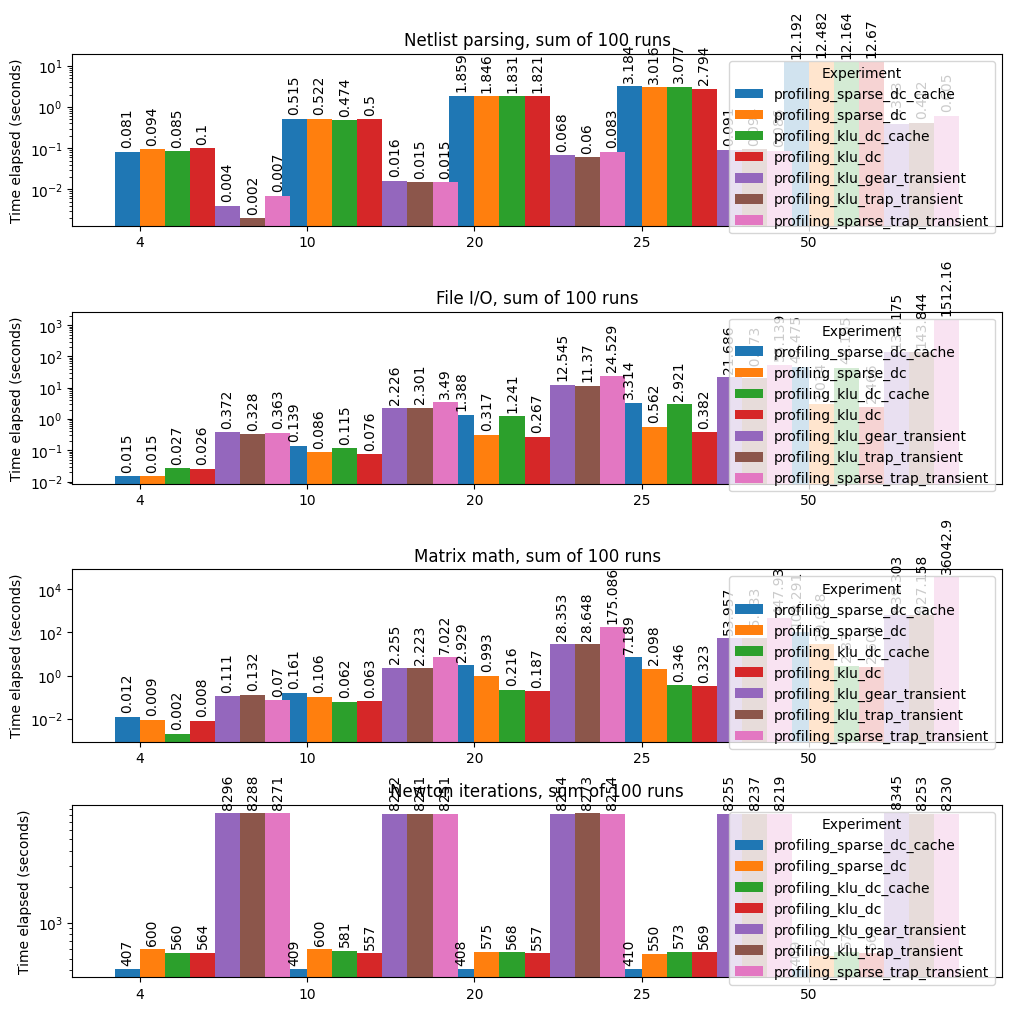

In [154]:
trial_data = stat_totals

task_type = {"Netlist parsing": netlist_fields, "File I/O": loading_fields, "Matrix math": matrix_fields, "Newton iterations": ["Total iterations"],}

x = np.arange(len(task_type))  # the label locations
width = 0.2  # the width of the bars
multiplier = 0

fig, axs = plt.subplots(len(task_type), layout='constrained', figsize=(10, 10))

# Create a grouped bar chart for each field
for ax, (category, fields) in zip(axs, task_type.items()):
    x = np.arange(len(stat_totals[EXPERIMENT_FNAMES[0]]["size"]))  # Label locations for sizes
    width = 0.15  # Width of the bars
    
    # Group data by experiment
    for i, experiment in enumerate(EXPERIMENT_FNAMES):
        experiment_data = sum(np.array(stat_totals[experiment][field]) for field in fields)
        ax.bar(x + i*width, experiment_data, width, label=experiment)
        ax.bar_label(ax.containers[i], label_type='edge', padding=3, rotation=90)

    # Add labels, title, and legend
    ax.set_ylabel('Time elapsed (seconds)')
    ax.set_title(f'{category}, sum of {N_ITERS} runs')
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(stat_totals[EXPERIMENT_FNAMES[0]]["size"])
    ax.legend(title='Experiment')
    ax.set_yscale('log')

# Show plot
plt.show()

/var/folders/p1/kynpdwyn2r5fmbpnr8d45m340000gn/T/ipykernel_88155/2709642183.py:27: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale('log')
/var/folders/p1/kynpdwyn2r5fmbpnr8d45m340000gn/T/ipykernel_88155/2709642183.py:27: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale('log')
/var/folders/p1/kynpdwyn2r5fmbpnr8d45m340000gn/T/ipykernel_88155/2709642183.py:27: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale('log')
/var/folders/p1/kynpdwyn2r5fmbpnr8d45m340000gn/T/ipykernel_88155/2709642183.py:30: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  fig.legend(artists, labels=EXPERIMENT_FNAMES, loc='lower left', framealpha=1.)


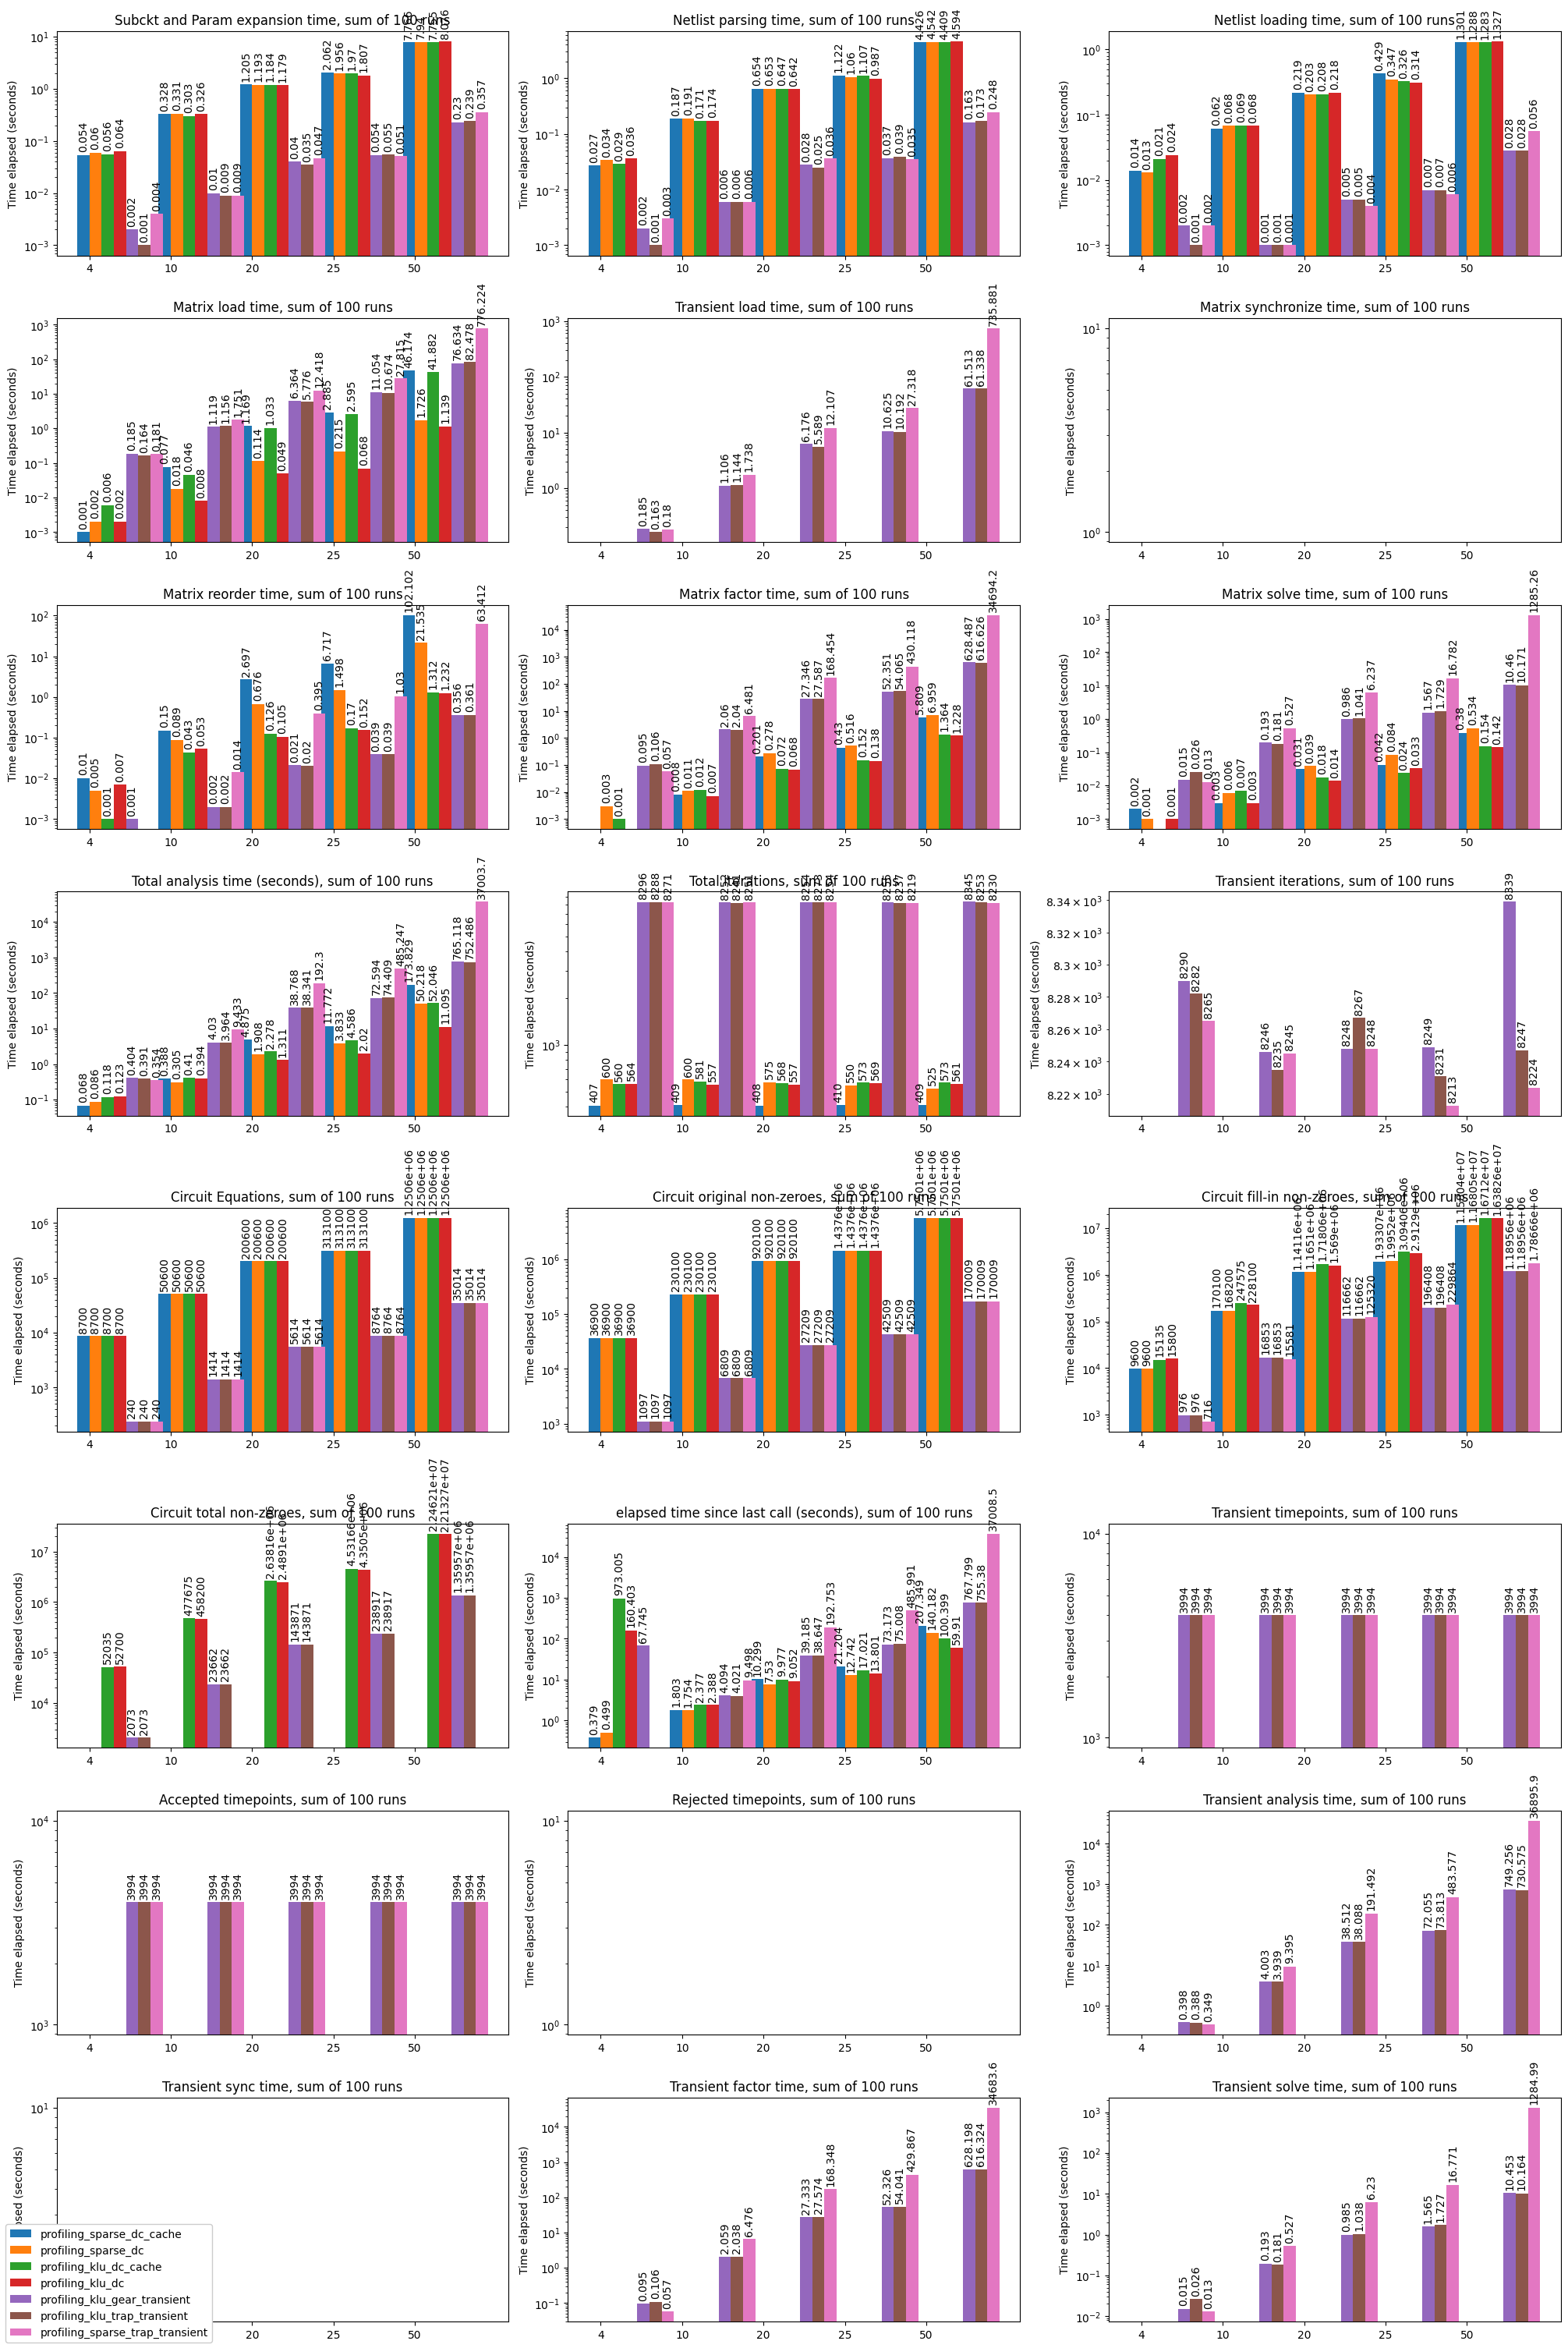

In [163]:
trial_data = stat_totals

x = np.arange(len(task_type))  # the label locations
width = 0.2  # the width of the bars
multiplier = 0

fig, axs = plt.subplots(len(all_fields)//3, 3, layout='constrained', figsize=(20, 30))

# Create a grouped bar chart for each field
for ax, field in zip(axs.flatten(), all_fields):
    x = np.arange(len(stat_totals[EXPERIMENT_FNAMES[0]]["size"]))  # Label locations for sizes
    width = 0.15  # Width of the bars
    
    # Group data by experiment
    artists = []
    for i, experiment in enumerate(EXPERIMENT_FNAMES):
        experiment_data = stat_totals[experiment][field]
        artists.append(ax.bar(x + i*width, experiment_data, width, label=experiment)) # one legend per graph
        ax.bar_label(ax.containers[i], label_type='edge', padding=3, rotation=90)

    # Add labels, title, and legend
    ax.set_ylabel('Time elapsed (seconds)')
    ax.set_title(f'{field}, sum of {N_ITERS} runs')
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(stat_totals[EXPERIMENT_FNAMES[0]]["size"])
    # ax.legend(title='Experiment')
    ax.set_yscale('log')

# Show plot
fig.legend(artists, labels=EXPERIMENT_FNAMES, loc='lower left', framealpha=1.)
# plt.tight_layout()
plt.show()

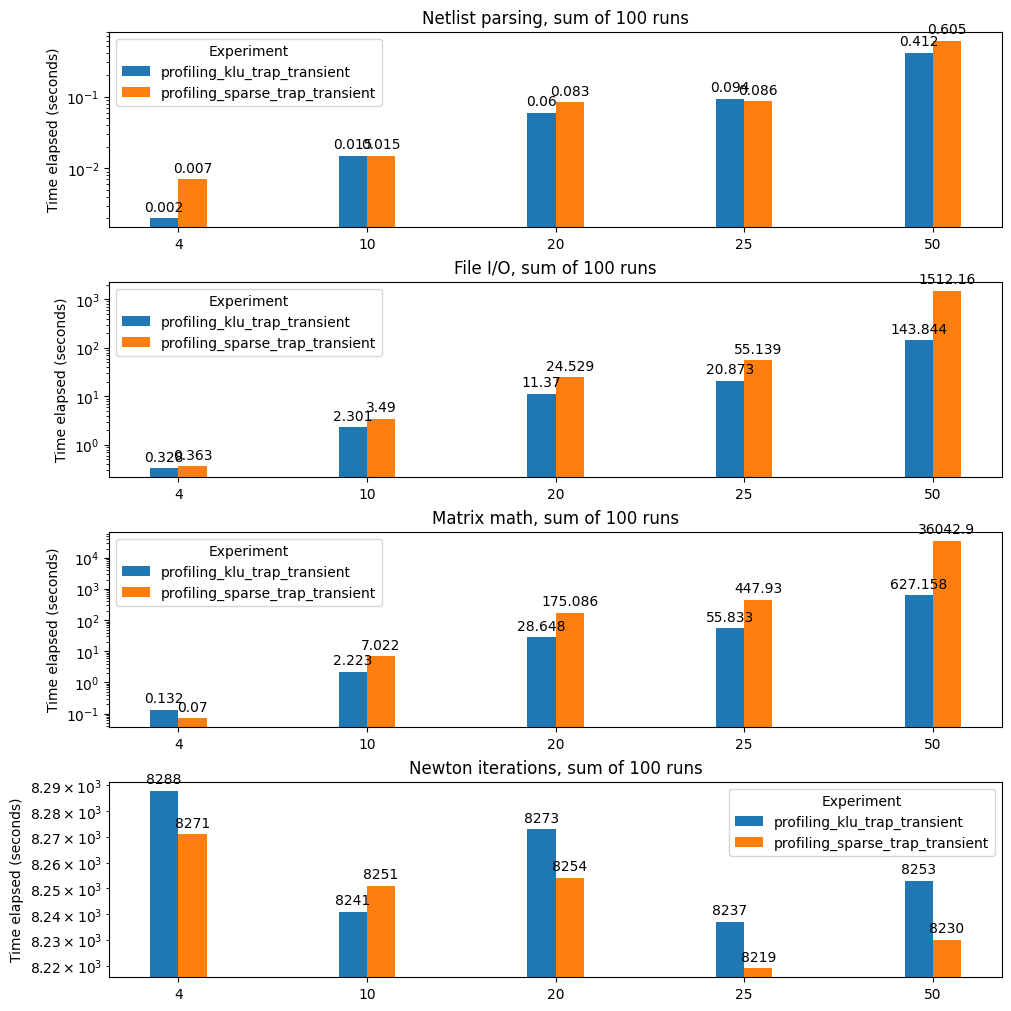

In [156]:
trial_data = stat_totals

task_type = {"Netlist parsing": netlist_fields, "File I/O": loading_fields, "Matrix math": matrix_fields, "Newton iterations": ["Total iterations"],}

x = np.arange(len(task_type))  # the label locations
width = 0.2  # the width of the bars
multiplier = 0

fig, axs = plt.subplots(len(task_type), layout='constrained', figsize=(10, 10))

# Create a grouped bar chart for each field
for ax, (category, fields) in zip(axs, task_type.items()):
    x = np.arange(len(stat_totals[EXPERIMENT_FNAMES[-1]]["size"]))  # Label locations for sizes
    width = 0.15  # Width of the bars
    
    # Group data by experiment
    for i, experiment in enumerate(EXPERIMENT_FNAMES[-2:]):
        experiment_data = sum(np.array(stat_totals[experiment][field]) for field in fields)
        ax.bar(x + i*width, experiment_data, width, label=experiment)
        ax.bar_label(ax.containers[i], label_type='edge', padding=3)

    # Add labels, title, and legend
    ax.set_ylabel('Time elapsed (seconds)')
    ax.set_title(f'{category}, sum of {N_ITERS} runs')
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(stat_totals[EXPERIMENT_FNAMES[-1]]["size"])
    ax.legend(title='Experiment')
    ax.set_yscale('log')

# Show plot
plt.show()

/var/folders/p1/kynpdwyn2r5fmbpnr8d45m340000gn/T/ipykernel_88155/316501627.py:28: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale('log')
/var/folders/p1/kynpdwyn2r5fmbpnr8d45m340000gn/T/ipykernel_88155/316501627.py:28: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale('log')
/var/folders/p1/kynpdwyn2r5fmbpnr8d45m340000gn/T/ipykernel_88155/316501627.py:28: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale('log')


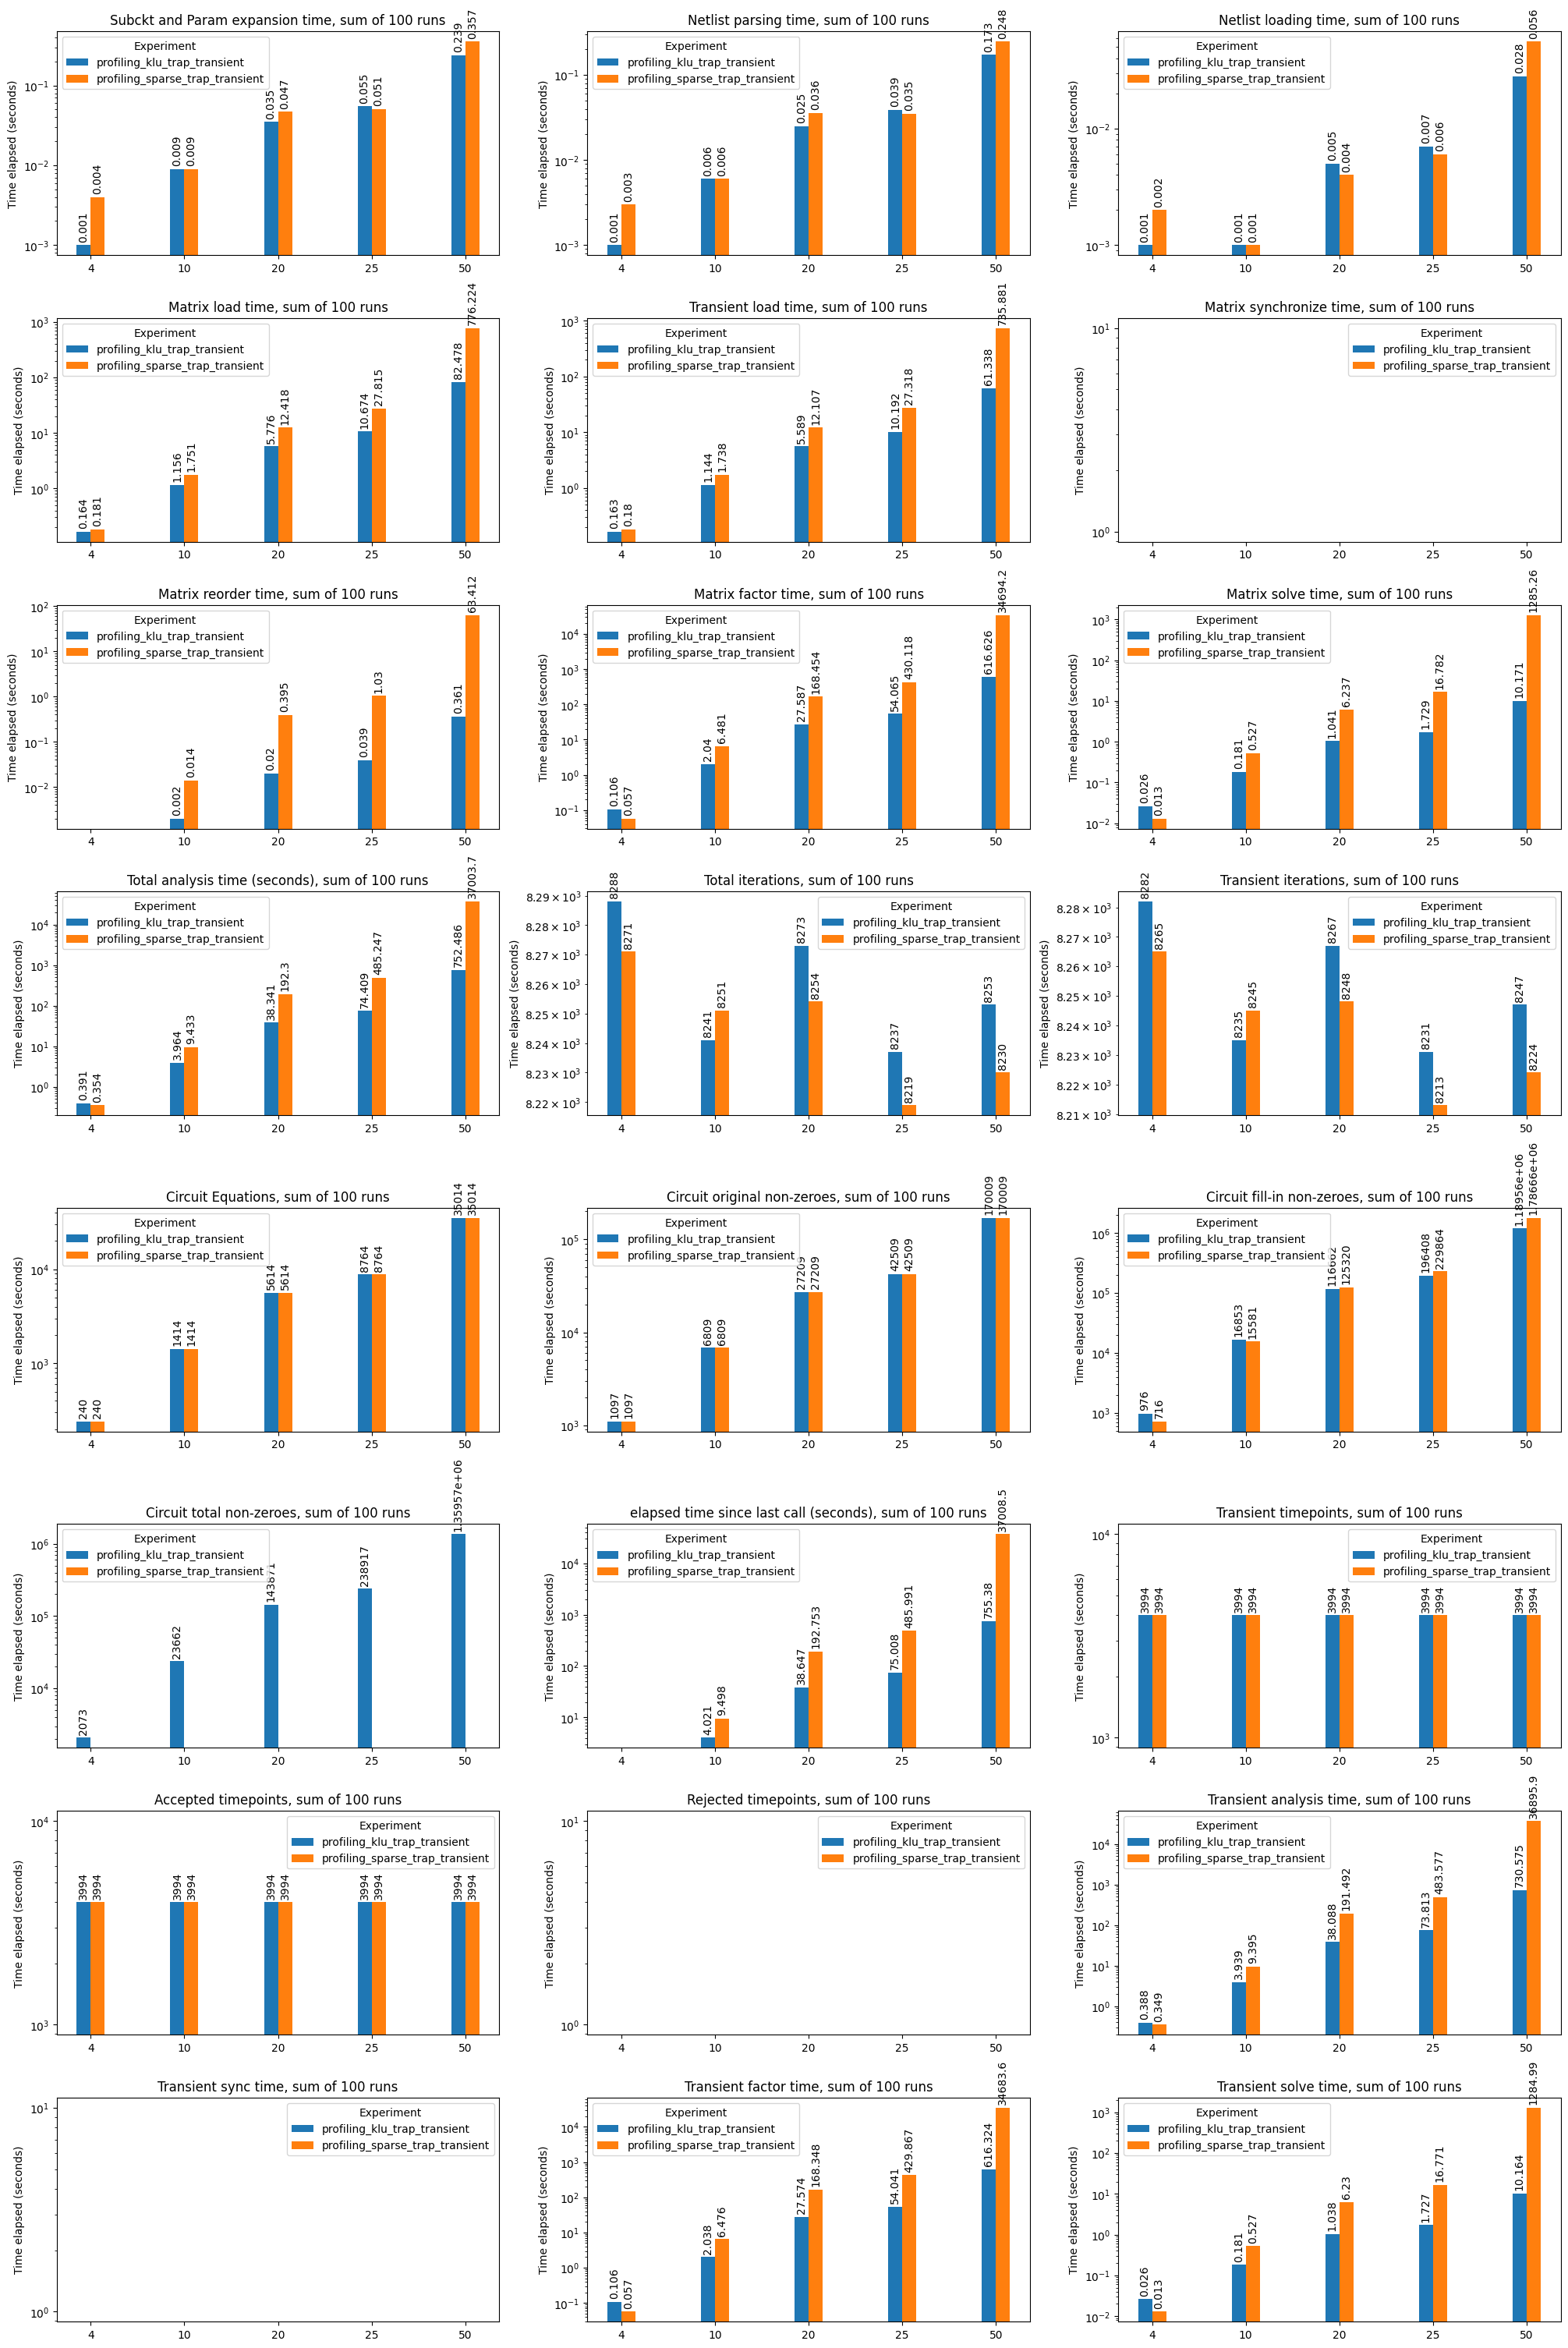

In [157]:
# for transient analyses

trial_data = stat_totals

x = np.arange(len(task_type))  # the label locations
width = 0.2  # the width of the bars
multiplier = 0

fig, axs = plt.subplots(len(all_fields)//3, 3, layout='constrained', figsize=(20, 30))

# Create a grouped bar chart for each field
for ax, field in zip(axs.flatten(), all_fields):
    x = np.arange(len(stat_totals[EXPERIMENT_FNAMES[-1]]["size"]))  # Label locations for sizes
    width = 0.15  # Width of the bars
    
    # Group data by experiment
    for i, experiment in enumerate(EXPERIMENT_FNAMES[-2:]):
        experiment_data = stat_totals[experiment][field]
        ax.bar(x + i*width, experiment_data, width, label=experiment)
        ax.bar_label(ax.containers[i], label_type='edge', padding=3, rotation=90)

    # Add labels, title, and legend
    ax.set_ylabel('Time elapsed (seconds)')
    ax.set_title(f'{field}, sum of {N_ITERS} runs')
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(stat_totals[EXPERIMENT_FNAMES[-1]]["size"])
    ax.legend(title='Experiment')
    ax.set_yscale('log')

# Show plot
plt.show()

In [ ]:
# pie chart showcasing the distribution of time spent on each task
fig, axs = plt.subplots(1, len(NET_SIZES), figsize=(15, 5))

for i, size in enumerate(NET_SIZES):
    # Get the time spent on each task for the current network size
    netlist_time = sum([statistics[str(size)][f] for f in netlist_fields])
    io_time = sum([statistics[str(size)][f] for f in loading_fields])
    math_time = sum([statistics[str(size)][f] for f in matrix_fields])

    # Data to plot
    times = [netlist_time, io_time, math_time]
    labels = ['Netlist parsing', 'File I/O', 'Matrix math']
    colors = ['skyblue', 'orange', 'lightgreen']

    # Plot pie chart
    axs[i].pie(times, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors)
    axs[i].set_title(f'{size}x{size} Network')

plt.tight_layout()
plt.show()


In [ ]:
# Assuming `fields` is the list of all tasks (across all categories)
fig, axs = plt.subplots(1, len(NET_SIZES), figsize=(15, 5))

# Get unique task labels from all the fields combined
all_tasks = netlist_fields + loading_fields + matrix_fields
colors = plt.cm.get_cmap('tab20', len(all_tasks))  # Generate distinct colors for each task

for i, size in enumerate(NET_SIZES):
    # Get time spent on each individual task for the current network size
    task_times = {f: statistics[str(size)][f] for f in all_tasks}

    # Data to plot
    times = list(task_times.values())
    labels = list(task_times.keys())

    # Plot pie chart without labels (we'll add a single legend later)
    axs[i].pie(times, autopct='%1.1f%%', startangle=140, colors=colors(range(len(labels))))
    axs[i].set_title(f'{size}x{size} Network')

# Create a single legend
fig.legend(labels, loc="center right", title="Task", bbox_to_anchor=(1.2, 0.5), fontsize='small')

plt.tight_layout()
plt.show()

## Comparing unoptimized vs. optimized code

In [103]:
baseline = json.load(open("profiling_baseline.json"))
opt1 = json.load(open("profiling_param_subckt.json"))
opt2 = json.load(open("profiling_globaldef.json"))
opt3 = json.load(open("profiling_globaldef_klu.json"))

In [ ]:
import matplotlib.pyplot as plt 

SIZE = str(20)

# grouped bar chart of size vs. time for each field
fig, axs = plt.subplots(3, 1, figsize=(10, 15))

for i, (category, fields) in enumerate(zip(["Netlist parsing", "File I/O", "Matrix math"], [netlist_fields, loading_fields, matrix_fields])):
    stat_totals = {
        "baseline": [baseline[SIZE][f] for f in fields],
        "parameterized subcircuit": [opt1[SIZE][f] for f in fields],
        "global model definitions": [opt2[SIZE][f] for f in fields],
        "KLU solver": [opt3[SIZE][f] for f in fields]
    }

    x = np.arange(len(fields))  # the label locations
    width = 0.2  # the width of the bars
    multiplier = 0

    for attribute, measurement in stat_totals.items():
        offset = width * multiplier
        rects = axs[i].bar(x + offset, measurement, width, label=f"{attribute}")
        axs[i].bar_label(rects, padding=3)
        multiplier += 1

    # Add some text for labels, title and custom x-axis tick labels, etc.
    axs[i].set_ylabel('Time elapsed (seconds)')
    axs[i].set_title(f'Comparison of time elapsed by task type on {SIZE}x{SIZE} grid ({category}), avg of {n_iters} runs')
    axs[i].set_xticks(x + width, fields)
    axs[i].legend(loc='upper left', ncols=1)
    # axs[i].set_ylim(0, 3)

plt.show()

In [ ]:
print(net)

In [ ]:
# compare number of equations, matrix nonzeros, and lines of netlist
print("Netlist lines")
print("  Baseline: ", [baseline[str(size)]['Netlist lines'] for size in NET_SIZES])
print("  Parameterized subcircuit: ", [opt1[str(size)]['Netlist lines'] for size in NET_SIZES])
print("  Global model: ", [opt2[str(size)]['Netlist lines'] for size in NET_SIZES])

print("Circuit Equations")
print("  Baseline: ", [baseline[str(size)]['Circuit Equations'] for size in NET_SIZES])
print("  Parameterized subcircuit: ", [opt1[str(size)]['Circuit Equations'] for size in NET_SIZES])
print("  Global model: ", [opt2[str(size)]['Circuit Equations'] for size in NET_SIZES])

print("Circuit original non-zeroes")
print("  Baseline: ", [baseline[str(size)]['Circuit original non-zeroes'] for size in NET_SIZES])
print("  Parameterized subcircuit: ", [opt1[str(size)]['Circuit original non-zeroes'] for size in NET_SIZES])
print("  Global model: ", [opt2[str(size)]['Circuit original non-zeroes'] for size in NET_SIZES])

print("Circuit fill-in non-zeroes")
print("  Baseline: ", [baseline[str(size)]['Circuit fill-in non-zeroes'] for size in NET_SIZES])
print("  Parameterized subcircuit: ", [opt1[str(size)]['Circuit fill-in non-zeroes'] for size in NET_SIZES])
print("  Global model: ", [opt2[str(size)]['Circuit fill-in non-zeroes'] for size in NET_SIZES])

In [ ]:
import matplotlib.pyplot as plt

# Data from your output
comp_fields = ['Netlist lines', 'Circuit Equations', 'Circuit original non-zeroes', 'Circuit fill-in non-zeroes']
netlist_metrics = {
    f: ([baseline[str(size)][f] for size in NET_SIZES], [opt1[str(size)][f] for size in NET_SIZES], [opt2[str(size)][f] for size in NET_SIZES])
    for f in comp_fields
}

# Plot configuration
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
titles = list(data.keys())

# Loop through and plot each metric
for i, (title, (baseline_metric, param_metric, global_metric)) in enumerate(netlist_metrics.items()):
    ax = axs[i // 2, i % 2]
    ax.plot(NET_SIZES, baseline_metric, label='Baseline', marker='o')
    ax.plot(NET_SIZES, param_metric, label='Parameterized Subckt', marker='o')
    ax.plot(NET_SIZES, global_metric, label='Global Model', marker='o')
    ax.set_title(title)
    ax.set_xlabel('Network Size')
    ax.set_ylabel(title.split()[-1])
    ax.legend()

plt.tight_layout()
plt.show()


In [ ]:
# find factor reduction in num lines
baseline_lines = [baseline[str(size)]['Netlist lines'] for size in NET_SIZES]
param_lines = [opt2[str(size)]['Netlist lines'] for size in NET_SIZES]

line_reduction = [bl / pl for bl, pl in zip(baseline_lines, param_lines)]
line_reduction

In [ ]:
# compare total times of runs for each
clock_time_baseline = [sum(baseline[str(size)][f] for f in netlist_fields + loading_fields + matrix_fields) for size in NET_SIZES]
clock_time_opt1 = [sum(opt1[str(size)][f] for f in netlist_fields + loading_fields + matrix_fields) for size in NET_SIZES]
clock_time_opt2 = [sum(opt2[str(size)][f] for f in netlist_fields + loading_fields + matrix_fields) for size in NET_SIZES]

print(clock_time_baseline)
print(clock_time_opt1)
print(clock_time_opt2)

speedups = [clock_time_baseline[i] / (clock_time_opt2[i]+1e-10) for i in range(len(NET_SIZES))]
speedups

In [ ]:
baseline['50']['Total analysis time (seconds)']

In [ ]:
# Determine what portion of the time is spent in each section for netlists of each size

netlist_time_baseline = [sum(baseline[str(size)][f] for f in netlist_fields) / baseline[str(size)]['Total analysis time (seconds)'] for size in NET_SIZES]
netlist_time_opt1 = [sum(opt1[str(size)][f] for f in netlist_fields) / opt1[str(size)]['Total analysis time (seconds)'] for size in NET_SIZES]
netlist_time_opt2 = [sum(opt2[str(size)][f] for f in netlist_fields) / opt2[str(size)]['Total analysis time (seconds)'] for size in NET_SIZES]

print("Netlist operations")
print("Baseline:", netlist_time_baseline)
print("Opt1:", netlist_time_opt1)
print("Opt2:", netlist_time_opt2)

loading_time_baseline = [sum(baseline[str(size)][f] for f in loading_fields) / baseline[str(size)]['Total analysis time (seconds)'] for size in NET_SIZES]
loading_time_opt1 = [sum(opt1[str(size)][f] for f in loading_fields) / opt1[str(size)]['Total analysis time (seconds)'] for size in NET_SIZES]
loading_time_opt2 = [sum(opt2[str(size)][f] for f in loading_fields) / opt2[str(size)]['Total analysis time (seconds)'] for size in NET_SIZES]

print("Loading operations")
print("Baseline:", loading_time_baseline)
print("Opt1:", loading_time_opt1)
print("Opt2:", loading_time_opt2)

matrix_time_baseline = [sum(baseline[str(size)][f] for f in matrix_fields) / baseline[str(size)]['Total analysis time (seconds)'] for size in NET_SIZES]
matrix_time_opt1 = [sum(opt1[str(size)][f] for f in matrix_fields) / opt1[str(size)]['Total analysis time (seconds)'] for size in NET_SIZES]
matrix_time_opt2 = [sum(opt2[str(size)][f] for f in matrix_fields) / opt2[str(size)]['Total analysis time (seconds)'] for size in NET_SIZES]

print("Matrix operations")
print("Baseline:", matrix_time_baseline)
print("Opt1:", matrix_time_opt1)
print("Opt2:", matrix_time_opt2)

In [61]:
# plt.plot(NET_SIZES[1:], speedups[1:], label="Speedup")
# plt.plot(NET_SIZES, clock_time_baseline, label="Baseline")
# plt.plot(NET_SIZES, clock_time_optim1, label="Optimized")

# plt.xlabel("Netlist number of nodes")
# plt.ylabel("Total time elapsed (s)")
# plt.title("Total time elapsed vs. netlist size")

In [ ]:
# see how long this thing takes just for fun
from helpers import *

test_net = make_test_net(4, instance)

train_inputs = data['inputs']
train_outputs = data['outputs']

NUM_CHECKPOINTS = 20
NUM_ITERATIONS = 100000

e1, e2 = [], []
for E in test_net.edges:
    a, b = list(map(int, E.edge.node_names[:2]))
    e1.append(a)
    e2.append(b)

for i in tqdm.trange(NUM_CHECKPOINTS):
        this_steps = min(
            NUM_ITERATIONS // NUM_CHECKPOINTS, NUM_ITERATIONS - i * (NUM_ITERATIONS // NUM_CHECKPOINTS)
        )
        random_samples = np.random.choice(
            len(train_inputs), size=this_steps, replace=True
        )
        preds = np.empty(this_steps)
        updates = np.empty((this_steps, len(test_net.edges)))

        for j in tqdm.trange(this_steps, leave=False):
            test_net, pred, update = step_network(
                test_net,
                train_inputs[random_samples[j]],
                train_outputs[random_samples[j]],
                e1, 
                e2,
                eta=0.3,
                gamma=1,
            )
            preds[j] = pred.item()
            updates[j] = update